# 03 — Univariate Flood Frequency Analysis: Plaine Morte GLOF Impact

Does removing GLOF-inflated peaks change the fitted GEV distribution, and are the 2011–2018 annual maxima consistent with the pre-GLOF reference?

| # | Method | Lecture Notes Reference |
|---|--------|------------------------|
| 1 | Setup & data loading | — |
| 2 | Annual block maxima | Module 2, §4.1 |
| 3 | Descriptive statistics | Module 1, §1.2 |
| 4 | GEV MLE fitting | Module 1, §1.4.2 · Module 2, §4.2.2 |
| 5 | Gringorten plotting positions | Module 1, Table 3.1 |
| 6 | T-year quantile estimation | Module 2, Eq. 4.22 |
| 7 | Confidence intervals (delta method) | Module 2, Eq. 4.26 |
| 8 | Return period plot | Module 2, §4.1.1 |
| 9 | GLOF window masking | — (data preparation) |
| 10 | Masked series analysis | Module 2, §4.1 |
| 11 | Design quantile table | Module 2, Eq. 4.22 |
| 12 | AIC model comparison | Module 2, §5.5.2, Eq. 5.12 |
| 13 | Reference GEV (1944–2010) | Module 2, §4.1, §4.2.2 |
| 14 | Probability integral transform | Module 1, §1.3.1 |
| 15 | Kolmogorov–Smirnov test | Module 1, §3.1.2 |
| 16 | P–P plot | Module 1, §3.2 |
| 17 | Three-curve GEV summary | Module 2, §4.2.2 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numpy.linalg import inv as mat_inv
from pathlib import Path

FIGS = Path("../figures")
FIGS.mkdir(exist_ok=True)

In [2]:
## Load raw daily discharge from GRDC file (station 6935331, Simme at Oberried/Lenk)
DISCHARGE_FILE = Path("../data/raw/discharge/2026-04-26_11-35/6935331_Q_Day.Cmd.txt")
Q_daily = (
    pd.read_csv(
        DISCHARGE_FILE, sep=";", comment="#", header=0,
        names=["date", "time", "Q_m3s"], parse_dates=["date"],
        na_values=["-999.000", "-999"], encoding="latin-1",
    )
    .set_index("date")["Q_m3s"]
    .pipe(pd.to_numeric, errors="coerce")
    .pipe(lambda s: s.where(s > 0))
    .sort_index()
)
print(f"Discharge record: {Q_daily.index[0].date()} to {Q_daily.index[-1].date()}")
print(f"Overall maximum: {Q_daily.max():.1f} m3/s")

Discharge record: 1944-01-01 to 2020-12-31
Overall maximum: 21.1 m3/s


In [3]:
## Confirmed GLOF dates from gletschersee-lenk.ch archive, Simmentalzeitung, 20min.ch, TC 2021
## 2016 excluded: no documented major outburst that year
GLOF_DATES = {
    2011: pd.Timestamp("2011-07-27"),
    2012: pd.Timestamp("2012-07-24"),
    2013: pd.Timestamp("2013-08-06"),
    2014: pd.Timestamp("2014-08-08"),
    2015: pd.Timestamp("2015-08-03"),
    2017: pd.Timestamp("2017-07-19"),
    2018: pd.Timestamp("2018-07-27"),
}
WINDOW = 5   # days to mask on each side of GLOF date
print("GLOF years:", list(GLOF_DATES.keys()))

GLOF years: [2011, 2012, 2013, 2014, 2015, 2017, 2018]


In [4]:
## ── Helper functions ──────────────────────────────────────────────────────────
## Used by multiple method cells below; definitions kept here to avoid repetition.

def gev_q(T, xi, mu, sigma):
    """GEV quantile for return period T (Module 2, §4.2.2 Eq. 4.21)."""
    yT = -np.log(1.0 - 1.0 / T)
    if abs(xi) < 1e-8:
        return mu - sigma * np.log(yT)      # Gumbel limit
    return mu + sigma * (yT**(-xi) - 1.0) / xi

def _gev_nll(params, data):
    xi, mu, sigma = params
    if sigma <= 0:
        return 1e20
    return -np.sum(stats.genextreme.logpdf(data, c=-xi, loc=mu, scale=sigma))

def _hessian(f, x0, eps=1e-4):
    """Numerical Hessian via central finite differences."""
    n, H = len(x0), np.zeros((len(x0), len(x0)))
    for i in range(n):
        for j in range(n):
            xpp = x0.copy(); xpp[i] += eps; xpp[j] += eps
            xpm = x0.copy(); xpm[i] += eps; xpm[j] -= eps
            xmp = x0.copy(); xmp[i] -= eps; xmp[j] += eps
            xmm = x0.copy(); xmm[i] -= eps; xmm[j] -= eps
            H[i, j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4 * eps**2)
    return H

def fit_gev(data, T_arr, alpha=0.05):
    """
    GEV MLE (Module 2 §4.2.1) + delta-method CIs on quantiles (Module 2 Eq. 4.26).
    scipy uses c = -xi convention; we convert back to standard xi.
    Returns: xi, mu, sigma, quantiles_array, ci_lo_array, ci_hi_array
    """
    c_, mu_, sigma_ = stats.genextreme.fit(data)
    xi_ = -c_
    V   = mat_inv(_hessian(lambda p: _gev_nll(p, data), np.array([xi_, mu_, sigma_])))
    z   = stats.norm.ppf(1 - alpha / 2)
    qs, lo, hi = [], [], []
    for T in T_arr:
        yT = -np.log(1 - 1 / T)
        q  = gev_q(T, xi_, mu_, sigma_)
        if abs(xi_) < 1e-8:
            grad = np.array([0.0, 1.0, -np.log(yT)])
        else:
            yTxi = yT**(-xi_)
            grad = np.array([
                sigma_ * (-(np.log(yT) * yTxi * xi_ + yTxi - 1)) / xi_**2,
                1.0,
                (yTxi - 1) / xi_,
            ])
        se = np.sqrt(max(float(grad @ V @ grad), 0.0))
        qs.append(q); lo.append(q - z * se); hi.append(q + z * se)
    return xi_, mu_, sigma_, np.array(qs), np.array(lo), np.array(hi)

T_plot = np.logspace(np.log10(1.01), np.log10(500), 300)

## 2 — Annual Block Maxima (Full Series)
**Lecture Notes:** Module 2, §4.1

The block maxima method selects the single highest observation within each fixed time block (here: one calendar year), yielding the Annual Maximum Series (AMS). This satisfies the independence and stationarity assumptions required for extreme value analysis. GLOF-inflated peaks may violate stationarity and are examined separately in §10.

In [5]:
# "A" = year-end alias in pandas <2.2; replace with "YE" in pandas >=2.2
Q_ann = Q_daily.resample("A").max()
Q_ann.index = Q_ann.index.year
Q_ann = Q_ann.dropna()
n_full = len(Q_ann)

print(f"Full series: n={n_full} years ({Q_ann.index[0]}-{Q_ann.index[-1]})")
print(f"  min={Q_ann.min():.2f}, max={Q_ann.max():.2f}, mean={Q_ann.mean():.2f} m3/s")
print("\nGLOF-year annual maxima vs GLOF date:")
for yr, dt in GLOF_DATES.items():
    print(f"  {yr}: Q_max = {Q_ann.get(yr, float('nan')):.2f} m3/s  (GLOF date: {dt.date()})")

Full series: n=77 years (1944-2020)
  min=8.03, max=21.09, mean=11.52 m3/s

GLOF-year annual maxima vs GLOF date:
  2011: Q_max = 15.08 m3/s  (GLOF date: 2011-07-27)
  2012: Q_max = 14.56 m3/s  (GLOF date: 2012-07-24)
  2013: Q_max = 14.99 m3/s  (GLOF date: 2013-08-06)
  2014: Q_max = 21.09 m3/s  (GLOF date: 2014-08-08)
  2015: Q_max = 10.11 m3/s  (GLOF date: 2015-08-03)
  2017: Q_max = 13.94 m3/s  (GLOF date: 2017-07-19)
  2018: Q_max = 19.24 m3/s  (GLOF date: 2018-07-27)


## 4 — GEV MLE Fitting + Delta-Method Confidence Intervals (Full Series)
**Lecture Notes:** Module 1, §1.4.2 · Module 2, §4.2.1–§4.2.2 · Eq. 4.26

The Generalized Extreme Value distribution encompasses three shape families depending on the shape parameter ξ: Gumbel (ξ = 0), Fréchet (ξ > 0, heavy tail), and Weibull (ξ < 0, bounded upper tail) — Module 2, §4.2.2. Parameters (μ, σ, ξ) are estimated by Maximum Likelihood (Module 1, §1.4.2). Confidence intervals on T-year quantiles are computed via the delta method: Var(x_T) = ∇g · [I(θ)]⁻¹ · ∇gᵀ, where I(θ) is the Fisher information matrix (Module 2, Eq. 4.26).

In [6]:
xi_f, mu_f, sigma_f, q_f, ci_lo_f, ci_hi_f = fit_gev(Q_ann.values, T_plot)
ll_f = np.sum(stats.genextreme.logpdf(Q_ann.values, -xi_f, mu_f, sigma_f))
aic_f = 2 * 3 - 2 * ll_f

print("GEV MLE — full series:")
print(f"  mu    = {mu_f:.4f}")
print(f"  sigma = {sigma_f:.4f}")
print(f"  xi    = {xi_f:.4f}")
print(f"  log L = {ll_f:.4f},  AIC = {aic_f:.2f}")
if xi_f > 0.05:
    print(f"  Shape: Frechet (xi={xi_f:.3f} > 0) — heavy tail")
elif xi_f < -0.05:
    print(f"  Shape: Weibull (xi={xi_f:.3f} < 0) — bounded upper tail")
else:
    print(f"  Shape: near-Gumbel (|xi|={abs(xi_f):.3f} < 0.05)")

GEV MLE — full series:
  mu    = 10.2115
  sigma = 1.7110
  xi    = 0.1698
  log L = -170.4641,  AIC = 346.93
  Shape: Frechet (xi=0.170 > 0) — heavy tail


## 5 — Gringorten Plotting Positions (Full Series)
**Lecture Notes:** Module 1, Table 3.1

Plotting positions assign empirical non-exceedance probabilities to ranked observations. The Gringorten formula F_i = (i − 0.44) / (N + 0.12) is optimised for the GEV/Gumbel family (reduces bias compared to the simpler Weibull formula i/(N+1)). The empirical return period is T_i = 1 / (1 − F_i) and is used to position observations on the return period plot.

In [7]:
def gringorten(data):
    """Module 1, Table 3.1: Gringorten plotting positions."""
    qs = np.sort(data)
    F  = (np.arange(1, len(data) + 1) - 0.44) / (len(data) + 0.12)
    return qs, 1.0 / (1.0 - F)

Qa_s, Ta_e = gringorten(Q_ann.values)
print(f"Gringorten positions: n={len(Qa_s)} points")
print(f"  F range: {(1 - 1/Ta_e[0]):.4f} – {(1 - 1/Ta_e[-1]):.4f}")
print(f"  T range: {Ta_e[0]:.2f} – {Ta_e[-1]:.1f} years")

Gringorten positions: n=77 points
  F range: 0.0073 – 0.9927
  T range: 1.01 – 137.7 years


## 8 — Return Period Plot (Full Series)
**Lecture Notes:** Module 2, §4.1.1 · Eq. 4.1–4.3

The return period T = 1/p is the average waiting time between events exceeding the T-year flood level (Module 2, §4.1.1). The plot overlays the Gringorten empirical points (§5) with the fitted GEV quantile curve and 95% delta-method CI band. GLOF-year maxima are highlighted in red to show how they compare to the fitted distribution.

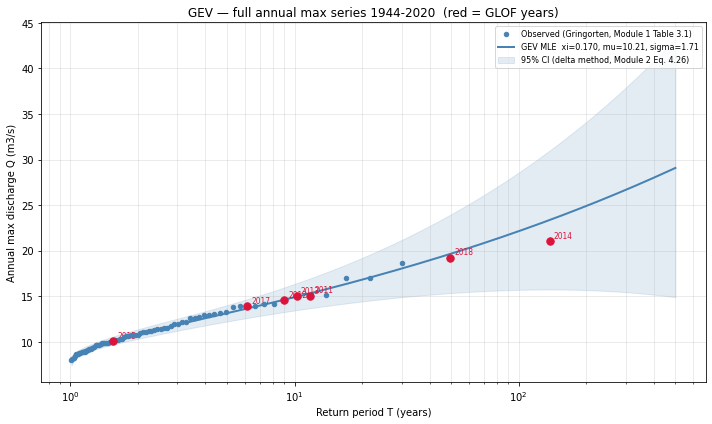

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(Ta_e, Qa_s, s=20, color="steelblue", zorder=4,
           label="Observed (Gringorten, Module 1 Table 3.1)")
ax.semilogx(T_plot, q_f, color="steelblue", lw=2,
            label=f"GEV MLE  xi={xi_f:.3f}, mu={mu_f:.2f}, sigma={sigma_f:.2f}")
ax.fill_between(T_plot, ci_lo_f, ci_hi_f, color="steelblue", alpha=0.15,
                label="95% CI (delta method, Module 2 Eq. 4.26)")

for yr, dt in GLOF_DATES.items():
    if yr in Q_ann.index:
        qv  = Q_ann[yr]
        idx = np.searchsorted(Qa_s, qv)
        te  = Ta_e[min(idx, n_full - 1)]
        ax.scatter(te, qv, color="crimson", zorder=5, s=55)
        ax.annotate(str(yr), (te, qv), xytext=(4, 3),
                    textcoords="offset points", fontsize=7.5, color="crimson")

ax.set_xlabel("Return period T (years)")
ax.set_ylabel("Annual max discharge Q (m3/s)")
ax.set_title("GEV — full annual max series 1944-2020  (red = GLOF years)")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
fig.savefig(FIGS / "03_gev_full.png", dpi=150)
plt.show()

## 9 — GLOF Window Masking (Data Preparation)
**Motivation:** Module 2, §4.1 (homogeneity requirement)

Module 2, §4.1 requires that all observations in the AMS come from the same generating process. GLOFs are driven by subglacial lake drainage — a physically distinct mechanism from rainfall and snowmelt floods. Setting a ±WINDOW day buffer around each confirmed GLOF date to NaN removes the GLOF hydrograph before re-extracting annual maxima. If the GLOF was the annual maximum, the masked series falls back to the next-highest non-GLOF day; if a rainfall flood was already higher, the annual maximum is unchanged.

In [9]:
Q_masked = Q_daily.copy()
for dt in GLOF_DATES.values():
    Q_masked.loc[
        (Q_masked.index >= dt - pd.Timedelta(days=WINDOW)) &
        (Q_masked.index <= dt + pd.Timedelta(days=WINDOW))
    ] = np.nan

print(f"Masked {len(GLOF_DATES)} GLOF windows (+/-{WINDOW} days each)")
masked_count = sum(
    ((Q_daily.index >= dt - pd.Timedelta(days=WINDOW)) &
     (Q_daily.index <= dt + pd.Timedelta(days=WINDOW))).sum()
    for dt in GLOF_DATES.values()
)
print(f"Total days set to NaN: {masked_count}")

Masked 7 GLOF windows (+/-5 days each)
Total days set to NaN: 77


## 10 — Annual Block Maxima (GLOF-Masked Series)
**Lecture Notes:** Module 2, §4.1

Same block maxima extraction as §2, applied to the masked discharge record (§9). This series represents the non-GLOF flood hydrology of the Simme and satisfies the homogeneity assumption of Module 2, §4.1. The table below shows which GLOF years had their annual maximum replaced and by how much.

In [10]:
Q_clean = Q_masked.resample("A").max()
Q_clean.index = Q_clean.index.year
Q_clean = Q_clean.dropna()
n_clean = len(Q_clean)

print(f"Masked series: n={n_clean} years  (dropped {n_full - n_clean} year(s) fully masked)")
print(f"  min={Q_clean.min():.2f}, max={Q_clean.max():.2f}, mean={Q_clean.mean():.2f} m3/s")
print(f"\n{'Year':>5}  {'Q_full':>8}  {'Q_clean':>9}  Change")
for yr in sorted(GLOF_DATES):
    fv = Q_ann.get(yr, np.nan)
    cv = Q_clean.get(yr, np.nan)
    if np.isnan(cv):
        note = "year dropped"
    elif abs(fv - cv) > 0.01:
        note = f"-{fv-cv:.2f} m3/s  (GLOF was annual max)"
    else:
        note = "unchanged  (rain/snow flood higher than GLOF)"
    print(f"{yr:>5}  {fv:>8.2f}  {cv:>9.2f}  {note}")

Masked series: n=77 years  (dropped 0 year(s) fully masked)
  min=8.03, max=18.65, mean=11.20 m3/s

 Year    Q_full    Q_clean  Change
 2011     15.08      15.08  unchanged  (rain/snow flood higher than GLOF)
 2012     14.56      14.56  unchanged  (rain/snow flood higher than GLOF)
 2013     14.99      11.10  -3.88 m3/s  (GLOF was annual max)
 2014     21.09      14.24  -6.84 m3/s  (GLOF was annual max)
 2015     10.11       9.11  -0.99 m3/s  (GLOF was annual max)
 2017     13.94      10.66  -3.28 m3/s  (GLOF was annual max)
 2018     19.24       9.81  -9.43 m3/s  (GLOF was annual max)


## 4b — GEV MLE Fitting + Delta-Method CIs (GLOF-Masked Series)
**Lecture Notes:** Module 1, §1.4.2 · Module 2, §4.2.1–§4.2.2 · Eq. 4.26

Identical MLE procedure as §4, applied to the GLOF-free annual maxima. A shift in the shape parameter ξ relative to the full-series estimate indicates how much the tail behaviour is driven by GLOFs. A more negative ξ in the masked series would imply that the apparent heavy tail in the full series was an artefact of GLOF contamination.

In [11]:
xi_c, mu_c, sigma_c, q_c, ci_lo_c, ci_hi_c = fit_gev(Q_clean.values, T_plot)
ll_c = np.sum(stats.genextreme.logpdf(Q_clean.values, -xi_c, mu_c, sigma_c))
aic_c = 2 * 3 - 2 * ll_c

print("GEV MLE — full series:   ", f"mu={mu_f:.4f}, sigma={sigma_f:.4f}, xi={xi_f:.4f}, AIC={aic_f:.2f}")
print("GEV MLE — GLOF-masked:   ", f"mu={mu_c:.4f}, sigma={sigma_c:.4f}, xi={xi_c:.4f}, AIC={aic_c:.2f}")

GEV MLE — full series:    mu=10.2115, sigma=1.7110, xi=0.1698, AIC=346.93
GEV MLE — GLOF-masked:    mu=10.1326, sigma=1.5801, xi=0.0932, AIC=328.16


## 11 — Design Quantile Table
**Lecture Notes:** Module 2, §4.2.1 · Eq. 4.22

The T-year GEV quantile is x_T = μ + (σ/ξ) · [y_T^(−ξ) − 1], where y_T = −ln(1 − 1/T) (Module 2, Eq. 4.22; Gumbel limit for ξ → 0). Comparing quantiles from the full and masked series quantifies how much GLOFs inflate estimated design flood levels at standard return periods used in engineering (10, 100, 200 years).

In [12]:
T_des = [2, 5, 10, 20, 50, 100, 200]
print(f"{'T (yr)':>7}  {'Q_full':>8}  {'CI_full':>14}  |  {'Q_masked':>9}  {'CI_masked':>14}  {'Delta(%)':>9}")
print("-" * 75)
for T in T_des:
    i = np.argmin(np.abs(T_plot - T))
    print(
        f"{T:>7}  {q_f[i]:>8.2f}  [{ci_lo_f[i]:>5.2f},{ci_hi_f[i]:>6.2f}]  |  "
        f"{q_c[i]:>9.2f}  [{ci_lo_c[i]:>5.2f},{ci_hi_c[i]:>6.2f}]  "
        f"{100*(q_c[i]-q_f[i])/q_f[i]:>+8.1f}%"
    )

 T (yr)    Q_full         CI_full  |   Q_masked       CI_masked   Delta(%)
---------------------------------------------------------------------------
      2     10.86  [10.34, 11.39]  |      10.73  [10.25, 11.20]      -1.3%
      5     13.13  [12.23, 14.03]  |      12.67  [11.93, 13.41]      -3.5%
     10     14.87  [13.43, 16.32]  |      14.07  [12.95, 15.19]      -5.4%
     20     16.83  [14.43, 19.22]  |      15.54  [13.77, 17.32]      -7.6%
     50     19.68  [15.35, 24.00]  |      17.57  [14.51, 20.62]     -10.7%
    100     22.11  [15.70, 28.51]  |      19.19  [14.81, 23.56]     -13.2%
    200     24.91  [15.68, 34.15]  |      20.96  [14.87, 27.05]     -15.9%


## 12 — AIC Model Comparison
**Lecture Notes:** Module 2, §5.5.2 · Eq. 5.12

The Akaike Information Criterion AIC = 2k − 2 ln(L̂) penalises model complexity (k parameters) relative to goodness of fit (log-likelihood L̂). Both GEV fits have k = 3, so ΔAIC = −2(ln L_masked − ln L_full). Because the two datasets differ in size, AIC values are shown for reference but are not directly comparable for model selection.

In [13]:
print("AIC comparison (Module 2, §5.5.2 Eq. 5.12):")
print(f"  GEV full series:    AIC = {aic_f:.2f}  (n={n_full})")
print(f"  GEV GLOF-masked:    AIC = {aic_c:.2f}  (n={n_clean})")
print()
print("Note: the datasets differ in size, so AIC values are not directly comparable")
print("for model selection. AIC is shown here for reference only.")

AIC comparison (Module 2, §5.5.2 Eq. 5.12):
  GEV full series:    AIC = 346.93  (n=77)
  GEV GLOF-masked:    AIC = 328.16  (n=77)

Note: the datasets differ in size, so AIC values are not directly comparable
for model selection. AIC is shown here for reference only.


## 8b — Return Period Comparison: Full vs. GLOF-Masked
**Lecture Notes:** Module 2, §4.1.1 · Eq. 4.1–4.3

Overlaid return period curves with Gringorten empirical points (Module 1, Table 3.1) and 95% delta-method CI bands (Module 2, Eq. 4.26). The right panel shows the relative difference (Q_masked − Q_full) / Q_full in percent, directly quantifying the GLOF-induced bias in design quantile estimates across all return periods.

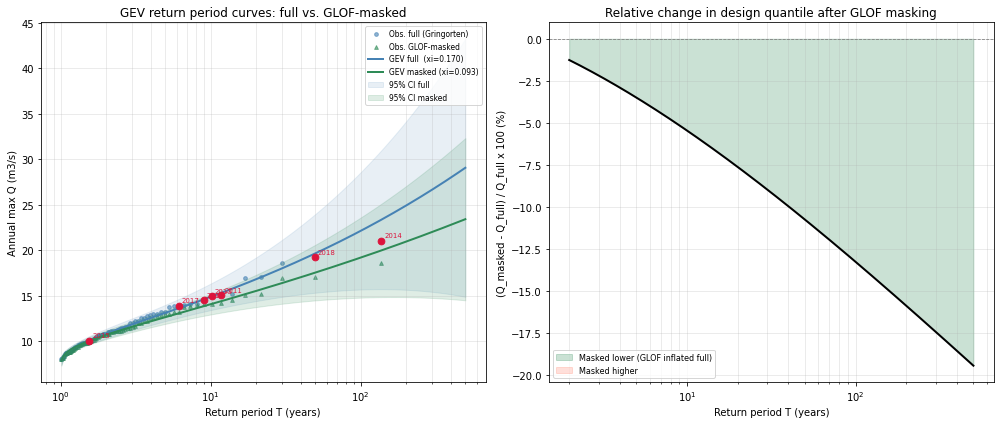

In [14]:
Qc_s, Tc_e = gringorten(Q_clean.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(Ta_e, Qa_s, s=14, color="steelblue", alpha=0.6, label="Obs. full (Gringorten)")
ax.scatter(Tc_e, Qc_s, s=14, marker="^", color="seagreen", alpha=0.6, label="Obs. GLOF-masked")
ax.semilogx(T_plot, q_f, color="steelblue", lw=2, label=f"GEV full  (xi={xi_f:.3f})")
ax.semilogx(T_plot, q_c, color="seagreen",  lw=2, label=f"GEV masked (xi={xi_c:.3f})")
ax.fill_between(T_plot, ci_lo_f, ci_hi_f, color="steelblue", alpha=0.12, label="95% CI full")
ax.fill_between(T_plot, ci_lo_c, ci_hi_c, color="seagreen",  alpha=0.15, label="95% CI masked")
for yr, dt in GLOF_DATES.items():
    if yr in Q_ann.index:
        qv  = Q_ann[yr]
        idx = np.searchsorted(Qa_s, qv)
        te  = Ta_e[min(idx, n_full - 1)]
        ax.scatter(te, qv, color="crimson", zorder=5, s=45)
        ax.annotate(str(yr), (te, qv), xytext=(3, 3),
                    textcoords="offset points", fontsize=7, color="crimson")
ax.set_xlabel("Return period T (years)")
ax.set_ylabel("Annual max Q (m3/s)")
ax.set_title("GEV return period curves: full vs. GLOF-masked")
ax.legend(fontsize=7.5)
ax.grid(True, which="both", alpha=0.3)

ax2 = axes[1]
T_mask   = T_plot >= 2
diff_pct = 100 * (q_c - q_f) / q_f
ax2.semilogx(T_plot[T_mask], diff_pct[T_mask], "k-", lw=2)
ax2.axhline(0, color="gray", lw=0.8, ls="--")
ax2.fill_between(T_plot[T_mask], diff_pct[T_mask], 0,
                 where=diff_pct[T_mask] < 0, color="seagreen", alpha=0.25,
                 label="Masked lower (GLOF inflated full)")
ax2.fill_between(T_plot[T_mask], diff_pct[T_mask], 0,
                 where=diff_pct[T_mask] > 0, color="tomato", alpha=0.20,
                 label="Masked higher")
ax2.set_xlabel("Return period T (years)")
ax2.set_ylabel("(Q_masked - Q_full) / Q_full x 100 (%)")
ax2.set_title("Relative change in design quantile after GLOF masking")
ax2.legend(fontsize=8)
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
fig.savefig(FIGS / "03_gev_comparison.png", dpi=150)
plt.show()

## 13 — Reference GEV: Pre-GLOF Period (1944–2010)
**Lecture Notes:** Module 2, §4.1 · §4.2.1–§4.2.2

Before 2011 the glacier had not yet thinned enough to open the subglacial northward drainage path, making GLOFs physically impossible. The 1944–2010 series is therefore a homogeneous reference (Module 2, §4.1 stationarity requirement). A GEV fitted by MLE to this independent sample serves as the null model for the statistical tests in §14–§16.

In [15]:
Q_ref = Q_ann[Q_ann.index <= 2010]
n_ref = len(Q_ref)

xi_r, mu_r, sigma_r, q_r, ci_lo_r, ci_hi_r = fit_gev(Q_ref.values, T_plot)
ll_r = np.sum(stats.genextreme.logpdf(Q_ref.values, -xi_r, mu_r, sigma_r))

print(f"Reference GEV (1944-2010): n={n_ref}")
print(f"  mu={mu_r:.4f}, sigma={sigma_r:.4f}, xi={xi_r:.4f}, AIC={2*3-2*ll_r:.2f}")
print()
print("Parameter comparison:")
print(f"  {'Series':<18}  {'xi':>8}  {'mu':>8}  {'sigma':>8}")
print(f"  {'Full 1944-2020':<18}  {xi_f:>8.4f}  {mu_f:>8.4f}  {sigma_f:>8.4f}")
print(f"  {'GLOF-masked':<18}  {xi_c:>8.4f}  {mu_c:>8.4f}  {sigma_c:>8.4f}")
print(f"  {'Ref 1944-2010':<18}  {xi_r:>8.4f}  {mu_r:>8.4f}  {sigma_r:>8.4f}")

Reference GEV (1944-2010): n=67
  mu=10.0376, sigma=1.5424, xi=0.1009, AIC=283.54

Parameter comparison:
  Series                    xi        mu     sigma
  Full 1944-2020        0.1698   10.2115    1.7110
  GLOF-masked           0.0932   10.1326    1.5801
  Ref 1944-2010         0.1009   10.0376    1.5424


## 14 — Probability Integral Transform
**Lecture Notes:** Module 1, §1.3.1

If X ~ F_θ then U = F_θ(X) ~ Uniform(0, 1) (Module 1, §1.3.1). Applying the reference GEV CDF to each 2011–2018 annual maximum gives u_i = F_ref(x_i). Under H₀ (no shift after 2011), these u_i should be uniformly distributed. Values near 1 indicate the observation is in the extreme upper tail of the reference distribution. Two groups are tested: **Group A** (GLOF-inclusive peaks) and **Group B** (GLOF-masked peaks).

In [16]:
test_years  = list(range(2011, 2019))
group_A     = Q_ann.reindex(test_years).dropna()    # GLOF-inclusive
group_B     = Q_clean.reindex(test_years).dropna()  # GLOF-masked

u_A = stats.genextreme.cdf(group_A.values, c=-xi_r, loc=mu_r, scale=sigma_r)
u_B = stats.genextreme.cdf(group_B.values, c=-xi_r, loc=mu_r, scale=sigma_r)

print("Probability integral transform u_i = F_ref(x_i):")
print(f"  Under H0, u_i ~ Uniform(0, 1)\n")
print(f"{'Year':>5}  {'Q_A':>7}  {'u_A':>7}  {'T_A (yr)':>10}  |  {'Q_B':>7}  {'u_B':>7}  {'T_B (yr)':>10}")
print("-" * 65)
for yr in test_years:
    qa  = group_A.get(yr, np.nan)
    qb  = group_B.get(yr, np.nan)
    ua  = stats.genextreme.cdf(qa, c=-xi_r, loc=mu_r, scale=sigma_r) if not np.isnan(qa) else np.nan
    ub  = stats.genextreme.cdf(qb, c=-xi_r, loc=mu_r, scale=sigma_r) if not np.isnan(qb) else np.nan
    Ta  = 1 / (1 - ua) if not np.isnan(ua) else np.nan
    Tb  = 1 / (1 - ub) if not np.isnan(ub) else np.nan
    print(f"{yr:>5}  {qa:>7.2f}  {ua:>7.4f}  {Ta:>10.1f}  |  {qb:>7.2f}  {ub:>7.4f}  {Tb:>10.1f}")

Probability integral transform u_i = F_ref(x_i):
  Under H0, u_i ~ Uniform(0, 1)

 Year      Q_A      u_A    T_A (yr)  |      Q_B      u_B    T_B (yr)
-----------------------------------------------------------------
 2011    15.08   0.9424        17.4  |    15.08   0.9424        17.4
 2012    14.56   0.9264        13.6  |    14.56   0.9264        13.6
 2013    14.99   0.9398        16.6  |    11.10   0.5986         2.5
 2014    21.09   0.9955       220.0  |    14.24   0.9140        11.6
 2015    10.11   0.3839         1.6  |     9.11   0.1565         1.2
 2016    13.97   0.9015        10.2  |    13.97   0.9015        10.2
 2017    13.94   0.9005        10.0  |    10.66   0.5104         2.0
 2018    19.24   0.9907       107.1  |     9.81   0.3127         1.5


## 15a — Kolmogorov–Smirnov Test: Group A (GLOF-Inclusive)
**Lecture Notes:** Module 1, §3.1.2

The KS test statistic D_n = max_i |F_n(u_i) − u_i| measures the maximum discrepancy between the empirical CDF of {u_i} and the Uniform(0,1) CDF (Module 1, §3.1.2). H₀: 2011–2018 full annual maxima are consistent with the reference GEV. The reference parameters come from independent 1944–2010 data, so no Lilliefors correction is needed. Note: n = 7–8 gives low statistical power.

In [17]:
ks_d_A, ks_p_A = stats.kstest(u_A, "uniform")
print("KS test — Group A (GLOF-inclusive):")
print(f"  H0: 2011-2018 full annual maxima ~ reference GEV (1944-2010)")
print(f"  D = {ks_d_A:.4f},  p = {ks_p_A:.4f}")
if ks_p_A < 0.05:
    print("  -> REJECT H0 at 5%: GLOF-inclusive peaks are NOT consistent with the pre-GLOF GEV.")
else:
    print(f"  -> Cannot reject H0 at 5% (p = {ks_p_A:.3f}).")
    print("     Low power expected with n=8; see individual u_i values above for outlier identification.")

KS test — Group A (GLOF-inclusive):
  H0: 2011-2018 full annual maxima ~ reference GEV (1944-2010)
  D = 0.7755,  p = 0.0000
  -> REJECT H0 at 5%: GLOF-inclusive peaks are NOT consistent with the pre-GLOF GEV.


## 15b — Kolmogorov–Smirnov Test: Group B (GLOF-Masked)
**Lecture Notes:** Module 1, §3.1.2

Same KS test applied to Group B (GLOF-masked 2011–2018 peaks). H₀: masked maxima are consistent with the reference GEV. If the mask correctly removes the GLOF signal, Group B should fail to reject H₀ while Group A rejects it — confirming that the distributional shift is attributable to GLOFs rather than to secular changes in rainfall or snowmelt hydrology.

In [18]:
ks_d_B, ks_p_B = stats.kstest(u_B, "uniform")
print("KS test — Group B (GLOF-masked):")
print(f"  H0: 2011-2018 GLOF-masked maxima ~ reference GEV (1944-2010)")
print(f"  D = {ks_d_B:.4f},  p = {ks_p_B:.4f}")
if ks_p_B < 0.05:
    print("  -> REJECT H0 at 5%: even after masking, peaks differ from the reference.")
else:
    print(f"  -> Cannot reject H0 at 5% (p = {ks_p_B:.3f}).")
    print("     GLOF-masked peaks are consistent with the pre-GLOF reference GEV.")
print()
print("Summary:")
print(f"  Group A (full):    D={ks_d_A:.4f}, p={ks_p_A:.4f}")
print(f"  Group B (masked):  D={ks_d_B:.4f}, p={ks_p_B:.4f}")

KS test — Group B (GLOF-masked):
  H0: 2011-2018 GLOF-masked maxima ~ reference GEV (1944-2010)
  D = 0.4015,  p = 0.1124
  -> Cannot reject H0 at 5% (p = 0.112).
     GLOF-masked peaks are consistent with the pre-GLOF reference GEV.

Summary:
  Group A (full):    D=0.7755, p=0.0000
  Group B (masked):  D=0.4015, p=0.1124


## 16 — P–P Plot: Groups A and B vs. Reference GEV
**Lecture Notes:** Module 1, §3.2

The probability–probability plot graphs the observed CDF value u_i = F_ref(x_i) against the expected uniform quantile (i − 0.5)/n (Module 1, §3.2). Points on the diagonal indicate perfect agreement with the reference. Points above the diagonal mean observations are heavier-tailed than the reference (GLOF inflation); points below indicate lighter tails. The left panel shows actual discharge values positioned on the reference GEV return period curve.

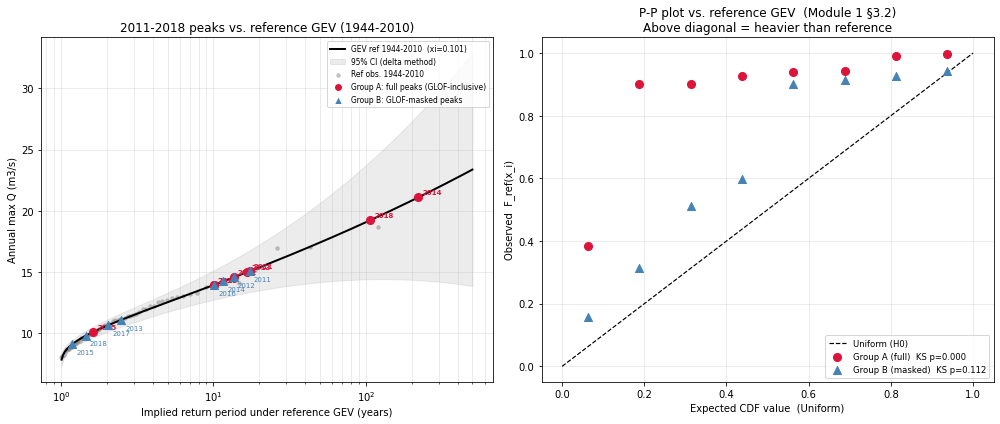

In [19]:
from matplotlib.lines import Line2D

Qr_s, Tr_e = gringorten(Q_ref.values)
T_A = 1 / (1 - u_A)
T_B = 1 / (1 - u_B)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: both groups positioned by implied return period on reference GEV
ax = axes[0]
ax.semilogx(T_plot, q_r, color="black", lw=2, label=f"GEV ref 1944-2010  (xi={xi_r:.3f})")
ax.fill_between(T_plot, ci_lo_r, ci_hi_r, color="gray", alpha=0.15, label="95% CI (delta method)")
ax.scatter(Tr_e, Qr_s, s=12, color="gray", alpha=0.4, label="Ref obs. 1944-2010")

for yr, q, Ti in zip(group_A.index, group_A.values, T_A):
    ax.scatter(Ti, q, color="crimson", marker="o", zorder=6, s=65)
    ax.annotate(str(yr), (Ti, q), xytext=(4, 3),
                textcoords="offset points", fontsize=7, color="crimson", fontweight="bold")
for yr, q, Ti in zip(group_B.index, group_B.values, T_B):
    ax.scatter(Ti, q, color="steelblue", marker="^", zorder=6, s=65)
    ax.annotate(str(yr), (Ti, q), xytext=(4, -10),
                textcoords="offset points", fontsize=7, color="steelblue")

legend_custom = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="crimson",
           ms=8, label="Group A: full peaks (GLOF-inclusive)"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="steelblue",
           ms=8, label="Group B: GLOF-masked peaks"),
]
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_custom, fontsize=7.5)
ax.set_xlabel("Implied return period under reference GEV (years)")
ax.set_ylabel("Annual max Q (m3/s)")
ax.set_title("2011-2018 peaks vs. reference GEV (1944-2010)")
ax.grid(True, which="both", alpha=0.3)

# Right: P-P plot (Module 1 §3.2)
ax2 = axes[1]
ax2.plot([0, 1], [0, 1], "k--", lw=1.2, label="Uniform (H0)")

for arr, color, marker, label, ks_p in [
    (u_A, "crimson",   "o", "Group A (full)",   ks_p_A),
    (u_B, "steelblue", "^", "Group B (masked)", ks_p_B),
]:
    n_pts    = len(arr)
    u_sorted = np.sort(arr)
    expected = (np.arange(1, n_pts + 1) - 0.5) / n_pts
    ax2.scatter(expected, u_sorted, color=color, marker=marker, s=65, zorder=5,
                label=f"{label}  KS p={ks_p:.3f}")

ax2.set_xlabel("Expected CDF value  (Uniform)")
ax2.set_ylabel("Observed  F_ref(x_i)")
ax2.set_title("P-P plot vs. reference GEV  (Module 1 §3.2)\nAbove diagonal = heavier than reference")
ax2.legend(fontsize=8.5)
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIGS / "03_reference_gev_test.png", dpi=150)
plt.show()

## 17 — Three-Curve GEV Summary
**Lecture Notes:** Module 2, §4.2.2 · Eq. 4.26

Final overlay of three GEV fits, each with 95% delta-method CI bands (Module 2, Eq. 4.26): the full 1944–2020 series (GLOF-inflated), the GLOF-masked series, and the pre-GLOF reference 1944–2010. Convergence of the masked and reference curves would confirm that GLOFs — not secular hydroclimatic change — are responsible for the distributional shift observed in the full record.

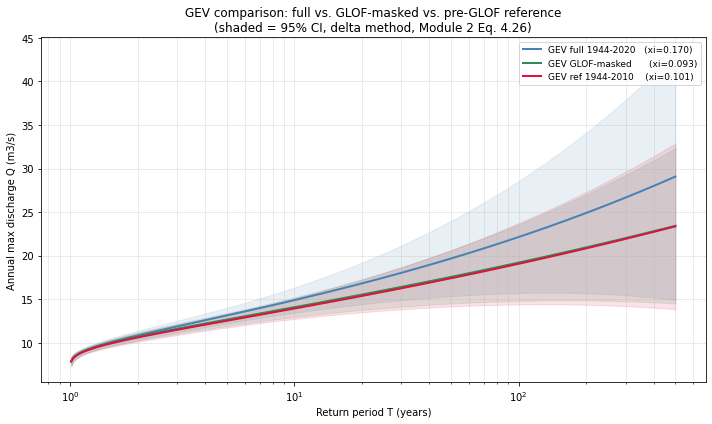

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

curves = [
    (q_f, ci_lo_f, ci_hi_f, "steelblue", f"GEV full 1944-2020   (xi={xi_f:.3f})"),
    (q_c, ci_lo_c, ci_hi_c, "seagreen",  f"GEV GLOF-masked      (xi={xi_c:.3f})"),
    (q_r, ci_lo_r, ci_hi_r, "crimson",   f"GEV ref 1944-2010    (xi={xi_r:.3f})"),
]
for q, lo, hi, color, label in curves:
    ax.semilogx(T_plot, q,  color=color, lw=2,   label=label)
    ax.fill_between(T_plot, lo, hi, color=color, alpha=0.12)

ax.set_xlabel("Return period T (years)")
ax.set_ylabel("Annual max discharge Q (m3/s)")
ax.set_title("GEV comparison: full vs. GLOF-masked vs. pre-GLOF reference\n"
             "(shaded = 95% CI, delta method, Module 2 Eq. 4.26)")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
fig.savefig(FIGS / "03_gev_three_curves.png", dpi=150)
plt.show()